<a href="https://colab.research.google.com/github/AYMAN-CHAREF/machine-learning-et-deep-learning/blob/main/Exemple_cour_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn .datasets import make_regression
from sklearn.model_selection import train_test_split
import scipy.stats as stats

In [2]:
X=np.array([100,110,120,130,140,150,160,170,180,190]).reshape(-1,1)
Y=np.array([45,51,50,61,66,70,72,78,85,85])
X,Y

(array([[100],
        [110],
        [120],
        [130],
        [140],
        [150],
        [160],
        [170],
        [180],
        [190]]),
 array([45, 51, 50, 61, 66, 70, 72, 78, 85, 85]))

In [3]:
Y=Y.reshape(-1,1)

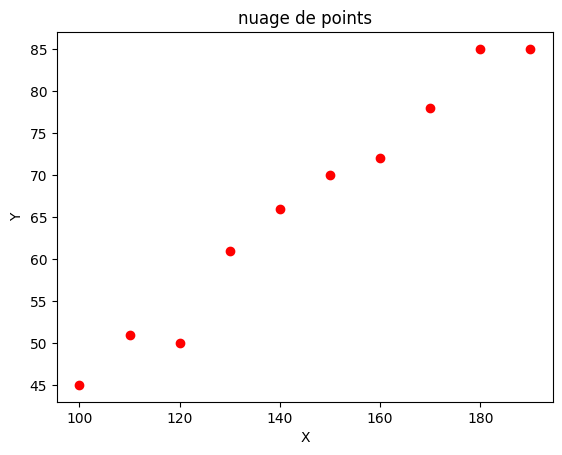

In [4]:
plt.scatter(X,Y,c='red')
plt.title("nuage de points")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [5]:
X_train=X
Y_train=Y
X_train.shape,Y_train.shape

((10, 1), (10, 1))

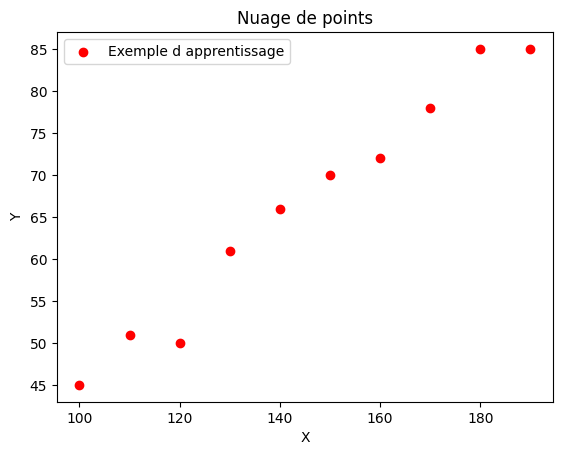

In [7]:
plt.scatter(X_train,Y_train,c='red',label="Exemple d apprentissage")

plt.legend()
plt.title("Nuage de points")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [8]:
def transformation_variables_explicatives(X):
  vect_un=np.ones((len(X),1))
  return np.hstack((X,vect_un))

In [9]:
def variance_estime(y_true,y_pred):
  n=len(y_true)
  return np.sum((y_true-y_pred)**2)/(n-2)

In [10]:
def varianceBeta1(X,Y_true,Y_pred):
  var_estim=variance_estime(Y_true,Y_pred)
  X_mean=np.mean(X)
  return var_estim/np.sum((X-X_mean)**2)

In [11]:
def model_lineaire_scalaire(X,Beta):
  return X*Beta[0]+Beta[1]  #X.dot(beta)

In [12]:
def moindres_carres(X,Y):
  X_mean=np.mean(X)
  Y_mean=np.mean(Y)
  beta_1=np.sum((X-X_mean)*(Y-Y_mean))/np.sum((X-X_mean)**2)
  beta_0=Y_mean-beta_1*X_mean
  return np.array([beta_1,beta_0])


In [13]:
Beta=moindres_carres(X_train,Y_train)
Beta

array([ 0.46969697, -1.80606061])

In [14]:
X_min=np.min(X_train)
X_max=np.max(X_train)
points=np.linspace(X_min,X_max,10)
points=points.reshape(-1,1)

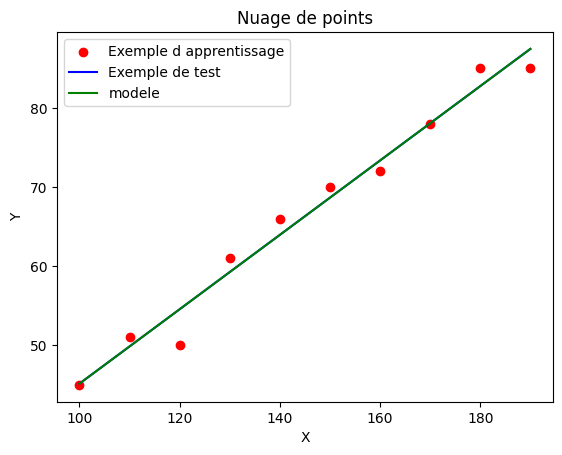

In [28]:
y_pred=model_lineaire_scalaire(points,Beta)
plt.scatter(X_train,Y_train,c='red',label="Exemple d apprentissage")
plt.plot(points,y_pred,c='blue',label="Exemple de test")
plt.plot(points,y_pred,c='green',label="modele")
plt.legend()
plt.title("Nuage de points")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [17]:
def ICB0(beta0 , y_true , y_pred , confiance=0.95) :
   n = len(y_true)
   ecartypeBeta0 = np.sqrt(varianceBeta0(X, y_true, y_pred))
   t = stats.t.ppf((1 + confiance) / 2, df=n-2)  # Correction ici !
   return (beta0 - t * ecartypeBeta0, beta0 + t * ecartypeBeta0)


In [18]:
def ICB1(beta1 , y_true , y_pred , confiance=0.95) :
   n = len(y_true)
   ecartypeBeta1 = np.sqrt(varianceBeta1(X,y_true,y_pred))  # Correction ici !
   t = stats.t.ppf(confiance, df=n-2)
   return (beta1 - t * ecartypeBeta1, beta1 + t * ecartypeBeta1)


In [19]:
def variance_estime(y_true,y_pred):
  n=len(y_true)
  return np.sum((y_true-y_pred)**2)/(n-2)

In [20]:
def varianceBeta1(X,Y_true,Y_pred):
  var_estim=variance_estime(Y_true,Y_pred)
  X_mean=np.mean(X)
  return var_estim/np.sum((X-X_mean)**2)

In [21]:
def varianceBeta0(X,Y_true,Y_pred):
  n=len(X)
  X_mean=np.mean(X)
  var_estim=variance_estime(Y_true,Y_pred)

  return var_estim*(1/n+X_mean**2/np.sum((X-X_mean)**2))

In [22]:
def transformation_variables_explicatives(X):
  vect_un=np.ones((len(X),1))
  return np.hstack((X,vect_un))

In [23]:
def moindres_carres_matricielle(X,Y):
  X=transformation_variables_explicatives(X)
  Beta_estimer=np.linalg.inv(X.T@X)@X.T@Y
  return Beta_estimer

In [24]:
def model_lineaire_matricielle(X,Beta):
  X=transformation_variables_explicatives(X)
  return X.dot(Beta)  #X.dot(beta)

In [25]:
Beta_estimer=moindres_carres_matricielle(X_train,Y_train)
Beta_estimer

array([[ 0.46969697],
       [-1.80606061]])

In [26]:
y_pred = model_lineaire_matricielle(X_train,Beta_estimer)
sigm2 =variance_estime(Y_train,y_pred)
var_beta0 = varianceBeta0(X_train,Y_train,y_pred)
var_beta1 = varianceBeta1(X_train,Y_train,y_pred)
print("sigm2 : ",sigm2)
print("var_beta0 : ",var_beta0)
print("var_beta1 : ",var_beta1)

sigm2 :  5.503030303030302
var_beta0 :  14.57469237832874
var_beta1 :  0.0006670339761248851


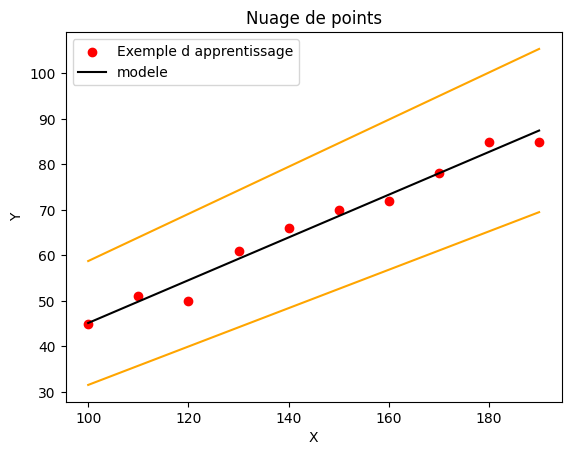

(array([-10.60965004]), array([6.99752882]))
(array([0.42167042]), array([0.51772352]))


In [27]:
X_obs = np.linspace(np.min(X_train),np.max(X_train),50).reshape(-1,1)
y_true = Y_train
y_pred = model_lineaire_matricielle(X_train,Beta_estimer)
y_pred_obs = model_lineaire_matricielle(X_obs,Beta_estimer)
beta0=Beta_estimer[1]
beta1=Beta_estimer[0]
ICB_0 = ICB0(beta0 , y_true , y_pred )
ICB_1 = ICB1(beta1 , y_true , y_pred )
y_pred_max = ICB_0[1] + ICB_1[1]*X_obs
y_pred_min = ICB_0[0] + ICB_1[0]*X_obs
plt.plot(X_obs,y_pred_max,c='orange')
plt.plot(X_obs,y_pred_min,c='orange')
y_pred=model_lineaire_scalaire(points,Beta)
plt.scatter(X_train,Y_train,c='red',label="Exemple d apprentissage")
plt.plot(points,y_pred,c='black',label="modele")
plt.legend()
plt.title("Nuage de points")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()
print(ICB_0)
print(ICB_1)